In [1]:
import SimpleITK as sitk
import numpy as np 
import matplotlib.pyplot as plt 

img_sitk = sitk.ReadImage('3702_left_knee.nii') 
img_sitk

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x73cd3203b4b0> >

In [2]:
image = sitk.GetArrayFromImage(img_sitk) 
image.shape

(216, 512, 512)

In [3]:
axial_index = image.shape[0] // 2      # 216 -> 108
coronal_index = image.shape[1] // 2    # 512 -> 256
sagittal_index = image.shape[2] // 2   # 512 -> 256

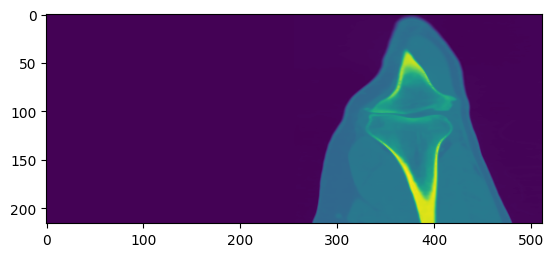

In [4]:
smoothed = sitk.CurvatureFlow(image1=img_sitk,
                               timeStep=0.225,
                               numberOfIterations=5)
plt.imshow(sitk.GetArrayFromImage(smoothed)[:, coronal_index, :])

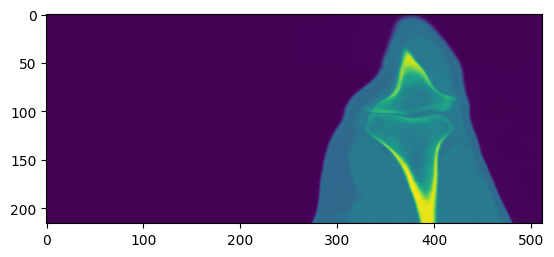

In [5]:
gaussian_blur = sitk.DiscreteGaussian(smoothed, variance=0.4)
gaussian_blur

plt.imshow(sitk.GetArrayFromImage(gaussian_blur)[:, coronal_index, :])

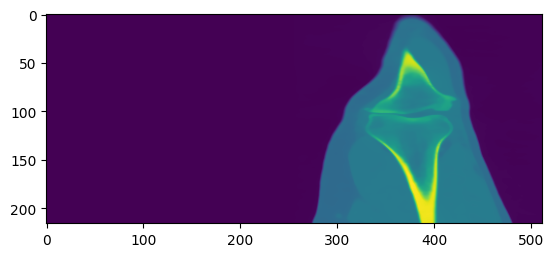

In [6]:
bilateral = sitk.Bilateral(gaussian_blur,
                           domainSigma=2.0,   # spatial extent
                           rangeSigma=50.0)
plt.imshow(sitk.GetArrayFromImage(bilateral)[:, coronal_index, :])

In [7]:
image_np = sitk.GetArrayFromImage(bilateral)
image_np.shape 

(216, 512, 512)

In [8]:
axial_slice = image_np[axial_index, :, :]       # shape: (512, 512)
coronal_slice = image_np[:, coronal_index, :]   # shape: (216, 512)
sagittal_slice = image_np[:, :, sagittal_index] # shape: (216, 512)

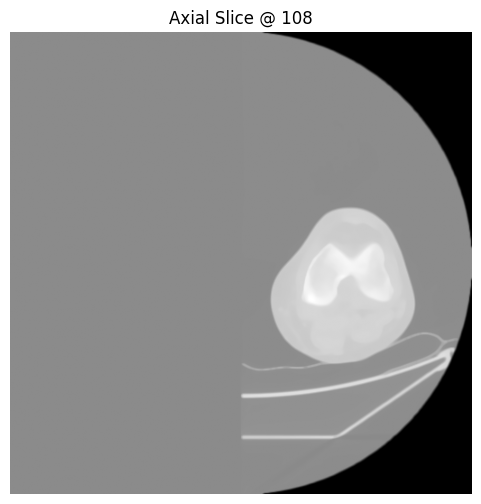

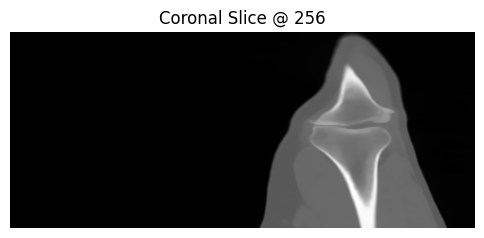

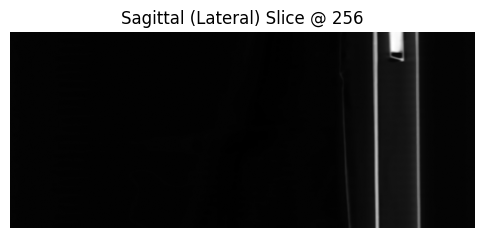

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(axial_slice, cmap='gray')
plt.title(f'Axial Slice @ {axial_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(coronal_slice, cmap='gray')
plt.title(f'Coronal Slice @ {coronal_index}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(sagittal_slice, cmap='gray')
plt.title(f'Sagittal (Lateral) Slice @ {sagittal_index}')
plt.axis('off')
plt.show()

(216, 512, 512) <class 'numpy.ndarray'>


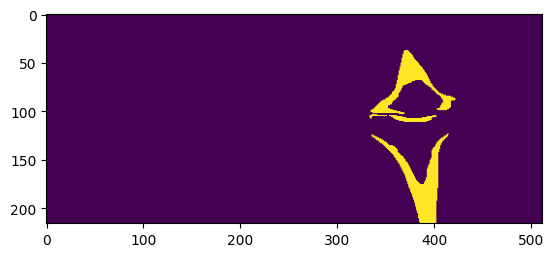

In [10]:
from skimage import filters, measure, morphology, segmentation, color, exposure
from scipy import ndimage as ndi

image = image_np

blurred = filters.gaussian(image, sigma=0.1)
print(blurred.shape, type(blurred))


threshold = 390
binary = image > threshold

plt.imshow(binary[:, coronal_index, :])

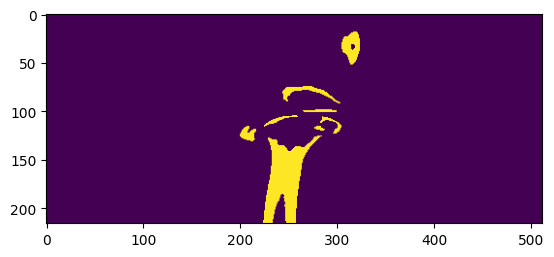

In [16]:
plt.imshow(binary[:, :, 400])

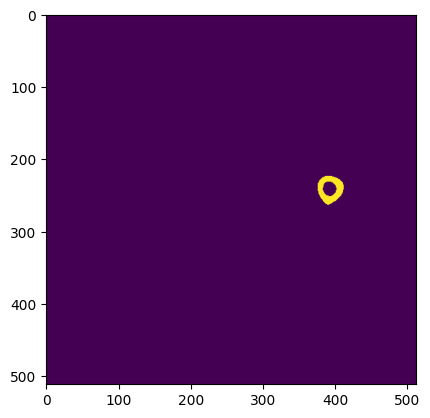

In [14]:
plt.imshow(binary[200, :, :])


In [25]:
binary = binary.astype(np.uint8)
binary.shape, binary.dtype, binary.min(), binary.max()

((216, 512, 512), dtype('uint8'), np.uint8(0), np.uint8(1))

In [23]:
# label connected components in 3d
cc_filter = sitk.ConnectedComponentImageFilter()
help(cc_filter)

Help on ConnectedComponentImageFilter in module SimpleITK.SimpleITK object:

class ConnectedComponentImageFilter(ImageFilter)
 |  Label the objects in a binary image.
 |
 |
 |  ConnectedComponentImageFilter labels the objects in a binary image (non-zero pixels are considered
 |  to be objects, zero-valued pixels are considered to be background).
 |  Each distinct object is assigned a unique label. The filter
 |  experiments with some improvements to the existing implementation, and
 |  is based on run length encoding along raster lines. If the output
 |  background value is set to zero (the default), the final object labels
 |  start with 1 and are consecutive. If the output background is set to a
 |  non-zero value (by calling the SetBackgroundValue() routine of the
 |  filter), the final labels start at 0, and remain consecutive except
 |  for skipping the background value as needed. Objects that are reached
 |  earlier by a raster order scan have a lower label. This is different
 | 

<class 'SimpleITK.SimpleITK.Image'>


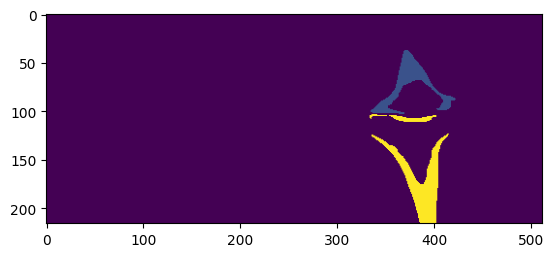

In [34]:
binary_image = sitk.GetImageFromArray(binary)
print(type(binary_image))
labeled = cc_filter.Execute(binary_image)
plt.imshow(sitk.GetArrayFromImage(labeled)[:, coronal_index, :])

In [40]:
# statistics on each component
stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(labeled)
labels = stats.GetLabels()
labels

(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)

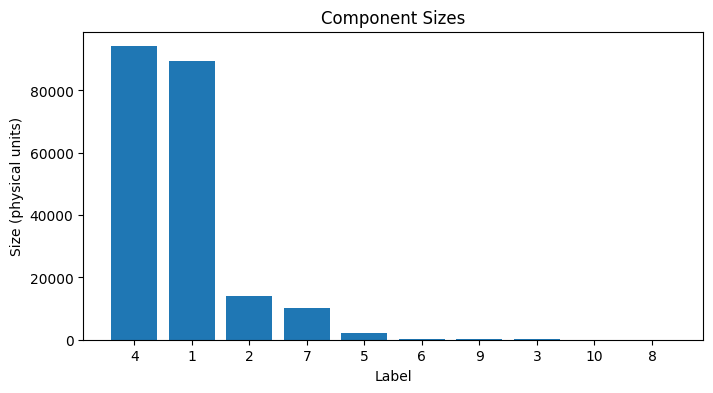

In [41]:
sizes = [stats.GetPhysicalSize(l) for l in labels]
sorted_pairs = sorted(zip(labels, sizes), key=lambda x: -x[1])

# Plot
plt.figure(figsize=(8, 4))
plt.bar([str(l) for l, _ in sorted_pairs], [s for _, s in sorted_pairs])
plt.title("Component Sizes")
plt.xlabel("Label")
plt.ylabel("Size (physical units)")
plt.show()

In [38]:
# get centroids and sort the components
centroids = {l: stats.GetCentroid(l) for l in stats.GetLabels()}
centroids

{1: (367.2798437063913, 273.8025565168853, 55.816611777839796),
 2: (402.77966101694915, 313.5565929330652, 39.961002585463945),
 3: (437.05, 301.29, 87.28),
 4: (381.6462989717005, 251.1183606696694, 157.56847539729753),
 5: (402.95325708602684, 295.6653406265539, 113.04226752859275),
 6: (419.31978319783195, 279.7235772357724, 113.36314363143632),
 7: (383.59423459244533, 207.19741550695824, 123.43598409542743),
 8: (393.0, 297.0, 112.0),
 9: (397.92, 281.2181818181818, 117.83272727272727),
 10: (361.0, 297.6666666666667, 123.66666666666667)}

In [39]:
sorted_labels = sorted(centroids.items(), key=lambda kv: kv[1][2])
sorted_labels

[(2, (402.77966101694915, 313.5565929330652, 39.961002585463945)),
 (1, (367.2798437063913, 273.8025565168853, 55.816611777839796)),
 (3, (437.05, 301.29, 87.28)),
 (8, (393.0, 297.0, 112.0)),
 (5, (402.95325708602684, 295.6653406265539, 113.04226752859275)),
 (6, (419.31978319783195, 279.7235772357724, 113.36314363143632)),
 (9, (397.92, 281.2181818181818, 117.83272727272727)),
 (7, (383.59423459244533, 207.19741550695824, 123.43598409542743)),
 (10, (361.0, 297.6666666666667, 123.66666666666667)),
 (4, (381.6462989717005, 251.1183606696694, 157.56847539729753))]